# Introduction

In this project I will be Analysing a global supersore dataset. I will be performing Data cleaning, transformation, indexing, grouping, merging, pivot tables, string operations, time series, and hierarchical indexing using pandas and numpy

### Importing Necessary Libraries

In [47]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [50]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

### 1. Loading and Explore the Data

In [120]:
# Loading the orders, returns and people datasets into pandas
file = r"C:\Users\User\desktop\Python-Class\Data\Global Superstore Data.xlsx"

orders = pd.read_excel(file, sheet_name="Orders")
returns = pd.read_excel(file, sheet_name="Returns")
people = pd.read_excel(file, sheet_name="People")

In [121]:
# Inspecting the shape of the orders dataframe
print(orders.shape)
orders.head()

(51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-BO-4861,"Ikea Library with Doors, Mobile",Bookcases,Furniture,731.82,2,0.0,102.42,39.66,Medium
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-SU-2988,"Acme Scissors, Easy Grip",Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,TEC-MA-4211,"Epson Receipt Printer, White",Machines,Technology,346.32,3,0.0,13.77,14.10,Medium
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-FU-5726,"Rubbermaid Door Stop, Erganomic",Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-EN-3664,"Cameo Interoffice Envelope, with clear poly wi...",Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium


In [ ]:
# Inspecting the descripton of the dataframe
orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2016-05-11 11:52:18.436342,2016-05-15 11:09:41.306297,55190.379428,246.490581,3.476545,0.142908,28.610982,26.478567
min,1.00000,2014-01-01 00:00:00,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.002000
25%,12823.25000,2015-06-19 00:00:00,2015-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2016-07-08 00:00:00,2016-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2017-05-22 00:00:00,2017-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2017-12-31 00:00:00,2018-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.251373


In [ ]:
# Inspecting the info of the dataframe
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  str           
 10  State           51290 non-null  str           
 11  Country         51290 non-null  str           
 12  Region          51290 non-null  str           
 13  Market          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Product Name 

In [ ]:
# Checking if type of orders["Sales"] is a series
type(orders["Sales"])

pandas.Series

In [ ]:
# Checking if type of orders([["Sales"]]) is a dataframe
type(orders[["Sales"]])

pandas.DataFrame

In [59]:
# Viewing just the Order ID, Customer Name, Sales and Profit columns
orders[["Order ID", "Customer Name", "Sales", "Profit"]].head()

,Order ID,Customer Name,Sales,Profit
0,IN-2017-CA120551-42816,Cathy Armstrong,731.82,102.42
1,ID-2015-BD116051-42248,Brian Dahlen,243.54,104.49
2,IN-2017-CA120551-42816,Cathy Armstrong,346.32,13.77
3,IN-2017-CA120551-42816,Cathy Armstrong,169.68,79.68
4,ID-2015-BD116051-42248,Brian Dahlen,203.88,24.36


In [63]:
# Viewing just the orders from the Africa market
africa_orders = orders[orders["Market"] == "Africa"]
africa_orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
71,50118,AG-2014-RO97803-41695,2014-02-25,2014-02-25,Same Day,RO-97803,Rose O'Brian,Consumer,NaN,Algiers,...,TEC-MA-4197,"Epson Inkjet, Durable",Machines,Technology,613.26,2,0.0,202.32,241.33,Critical
72,45891,AG-2015-TS115053-42337,2015-11-29,2015-12-02,First Class,TS-115053,Tony Sayre,Consumer,NaN,Algiers,...,FUR-BO-3901,"Dania Library with Doors, Metal",Bookcases,Furniture,1447.44,4,0.0,506.52,199.04,Medium
73,50119,AG-2014-RO97803-41695,2014-02-25,2014-02-25,Same Day,RO-97803,Rose O'Brian,Consumer,NaN,Algiers,...,OFF-ST-4081,"Eldon Lockers, Wire Frame",Storage,Office Supplies,393.96,2,0.0,78.78,110.60,Critical
74,50763,AG-2016-NF85953-42561,2016-07-10,2016-07-12,Second Class,NF-85953,Nicole Fjeld,Home Office,NaN,Algiers,...,TEC-PH-5356,"Nokia Smart Phone, with Caller ID",Phones,Technology,638.91,1,0.0,229.98,93.82,High
75,48480,AG-2016-DJ35103-42608,2016-08-26,2016-08-29,Second Class,DJ-35103,Don Jones,Corporate,NaN,Algiers,...,TEC-MA-4205,"Epson Printer, Durable",Machines,Technology,1050.96,4,0.0,399.36,64.78,Medium


### 2. Cleaning and Preparing the Data

In [66]:
# Checking for null values in the orders dataset
null_orders = orders.isnull().sum()
print("Null values in orders dataset:\n", null_orders)
print("There are {} null values in the orders dataset.".format(null_orders.sum()))

# `.format` here is used to format the string by replacing the curly braces {} with the value of null_orders.sum(), which gives the total number of null values in the orders dataset.

Null values in orders dataset:
 Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Product Name          0
Sub-Category          0
Category              0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64
There are 41296 null values in the orders dataset.


In [71]:
# # Checking for null values in the returns dataset
returns_people = returns.isnull().sum()
print("Null values in orders dataset:\n", returns_people)

print("There are {} null values in the orders dataset.".format(returns_people.sum()))

Null values in orders dataset:
 Returned    0
Order ID    0
Region      0
dtype: int64
There are 0 null values in the orders dataset.


In [72]:
# # Checking for null values in the people dataset
null_people = people.isnull().sum()
print("Null values in orders dataset:\n", null_people)

print("There are {} null values in the orders dataset.".format(null_people.sum()))

Null values in orders dataset:
 Person    0
Region    0
dtype: int64
There are 0 null values in the orders dataset.


In [104]:
# Replacing missing Postal Codes with 'Unknown'
orders['Postal Code'] = orders['Postal Code'].fillna('Unknown')

# `fillna` here replaces all Nan values in the 'Postal Code' column with 'Unknown'. This is useful for handling missing data in the dataset.

In [105]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,FUR-BO-4861,"Ikea Library with Doors, Mobile",Bookcases,Furniture,731.82,2,0.0,102.42,39.66,Medium
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,OFF-SU-2988,"Acme Scissors, Easy Grip",Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,TEC-MA-4211,"Epson Receipt Printer, White",Machines,Technology,346.32,3,0.0,13.77,14.10,Medium
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,FUR-FU-5726,"Rubbermaid Door Stop, Erganomic",Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,OFF-EN-3664,"Cameo Interoffice Envelope, with clear poly wi...",Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium


In [76]:
# Checking for duplicates on each dataset
print("Orders duplicates:", orders.duplicated().sum())
print("People duplicates:", people.duplicated().sum())
print("Returns duplicates:", returns.duplicated().sum())

Orders duplicates: 0
People duplicates: 0
Returns duplicates: 63


In [86]:
# Viewing duplicates in the first 5 rows of the returns dataset
returns[returns.duplicated()].sort_values("Order ID").head()

,Returned,Order ID,Region
172,Yes,BO-2017-DB291013-42745,Eastern Europe
1942,Yes,CA-2014-BM11140140-41889,Central US
1656,Yes,CA-2014-DS13030140-41828,Western US
1846,Yes,CA-2014-EA14035140-41977,Eastern US
1668,Yes,CA-2014-JP15520140-41951,Western US


In [87]:
orders.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Postal Code              float64
City                         str
State                        str
Country                      str
Region                       str
Market                       str
Product ID                   str
Product Name                 str
Sub-Category                 str
Category                     str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority               str
dtype: object

In [89]:
# Fixing orders.dtypes for 'Postal Code'
orders["Postal Code"] = orders["Postal Code"].astype("Int64").astype("string")
orders["Postal Code"].head()

0    <NA>
1    <NA>
2    <NA>
3    <NA>
4    <NA>
Name: Postal Code, dtype: string

In [90]:
# Fixed
orders.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Postal Code               string
City                         str
State                        str
Country                      str
Region                       str
Market                       str
Product ID                   str
Product Name                 str
Sub-Category                 str
Category                     str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority               str
dtype: object

In [91]:
# Checking data types for Order date and Ship date
orders[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [92]:
# Checking if the orders description makes sense
orders[["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982,26.478567
std,487.565361,2.278766,0.212280,174.340972,57.251373
min,0.444000,1.000000,0.000000,-6599.978000,1.002000
25%,30.758625,2.000000,0.000000,0.000000,2.610000
50%,85.053000,3.000000,0.000000,9.240000,7.790000
75%,251.053200,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [122]:
# Creating shipping duration column
orders["Shipping Duration"] = (orders["Ship Date"] - orders["Order Date"]).dt.days

### 3. Performing Operations on the Data

In [96]:
# Calculating total sales, total profit, total quantity, average discount and total shipping costs
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
total_quantity = orders["Quantity"].sum()
avg_discount = orders["Discount"].mean()
total_shipping = orders["Shipping Cost"].sum()

print(f"Total sales:         {total_sales:,.2f}")
print(f"Total profit:        {total_profit:,.2f}")
print(f"Total quantity sold: {total_quantity:,}")
print(f"Average discount:    {avg_discount:.2%}")
print(f"Total shipping cost: {total_shipping:,.2f}")

# Currency is undefined

Total sales:         12,642,501.91
Total profit:        1,467,457.29
Total quantity sold: 178,312
Average discount:    14.29%
Total shipping cost: 1,358,085.70


In [97]:
# Calculating shipping duration
orders["Shipping Duration"] = (orders["Ship Date"] - orders["Order Date"]).dt.days

# Subtracting two dates gives a time difference, and .dt.days turns it into a plain number

# Running a description of the shipping duration to make sure the mean isn't negative
orders["Shipping Duration"].describe()

count    51290.000000
mean         3.970404
std          1.730238
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          8.000000
Name: Shipping Duration, dtype: float64

In [98]:
# Calculating overall profil margin
overall_margin = total_profit / total_sales * 100
print(f"Overall profit margin: {overall_margin:.2f}%")

Overall profit margin: 11.61%


In [123]:
# Creating Profit Margin column
orders["Profit Margin"] = orders["Profit"] / orders["Sales"] * 100

In [124]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping Duration,Profit Margin
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Bookcases,Furniture,731.82,2,0.0,102.42,39.66,Medium,7,13.995245
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium,3,42.904656
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Machines,Technology,346.32,3,0.0,13.77,14.10,Medium,7,3.976091
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium,7,46.958982
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium,3,11.948205


In [125]:
cols = ["Order ID", "Product Name", "Sales", "Profit", "Profit Margin"]

print("Highest margins:")
display(orders.nlargest(5, "Profit Margin")[cols])

print("Lowest margins:")
display(orders.nsmallest(5, "Profit Margin")[cols])

# nlargest and nsmallest pick the top or bottom rows by a column. Expect lots of ties at the top and some very negative values at the bottom.

Highest margins:


,Order ID,Product Name,Sales,Profit,Profit Margin
241,AG-2017-CL25653-42895,"KitchenAid Refrigerator, White",1052.16,526.08,50.0
780,AM-2014-HM49806-41986,"Advantus Door Stop, Durable",42.06,21.03,50.0
1115,IN-2015-MP179657-42350,"Fellowes File Cart, Single Width",274.68,137.34,50.0
1721,IN-2014-RC198257-41897,"Novimex Legal Exhibit Labels, 5000 Label Set",21.72,10.86,50.0
1755,IN-2017-DB136157-43073,"Fellowes File Cart, Single Width",274.68,137.34,50.0


Lowest margins:


,Order ID,Product Name,Sales,Profit,Profit Margin
16441,IT-2015-MW1823548-42324,"Chromcraft Coffee Table, Fully Assembled",241.704,-1144.116,-473.354185
39004,IT-2015-NB18580139-42023,"Deflect-O Clock, Black",70.434,-271.236,-385.092427
31529,ID-2015-BG1103597-42147,"Hon Coffee Table, Fully Assembled",63.474,-244.386,-385.017487
31692,ID-2014-GP1474097-41776,"Hon Coffee Table, Fully Assembled",126.948,-488.772,-385.017487
31728,ID-2016-TN2104097-42469,"Lesro Training Table, Adjustable Height",108.396,-390.264,-360.035426


In [127]:
# Checking products with the highest and lowest profit margins.
product_margin = orders.groupby("Product Name").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
)
product_margin["margin_pct"] = product_margin["total_profit"] / product_margin["total_sales"] * 100

print("Highest product margins:")
display(product_margin.sort_values("margin_pct", ascending=False).head(5))

print("Lowest product margins:")
display(product_margin.sort_values("margin_pct").head(5))

Highest product margins:


,total_sales,total_profit,margin_pct
Product Name,,,
Avery 475,266.40,133.20,50.0
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier,3991.98,1995.99,50.0
Southworth Structures Collection,72.80,36.40,50.0
Xerox 1890,244.70,122.35,50.0
"Adams Telephone Message Book w/Frequently-Called Numbers Space, 400 Messages per Book",223.44,111.72,50.0


Lowest product margins:


,total_sales,total_profit,margin_pct
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,-275.000000
"Chromcraft Training Table, Adjustable Height",38.144,-87.7360,-230.012584
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",90.882,-190.8522,-210.000000
Euro Pro Shark Stick Mini Vacuum,170.744,-325.6332,-190.714286
"Chromcraft Coffee Table, Fully Assembled",1226.424,-1960.6960,-159.870974


In [128]:
# Checking orders with the highest and lowest profit margins
order_margin = orders.groupby("Order ID").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
)
order_margin["margin_pct"] = order_margin["total_profit"] / order_margin["total_sales"] * 100

display(order_margin.sort_values("margin_pct", ascending=False).head(5))
display(order_margin.sort_values("margin_pct").head(5))

,total_sales,total_profit,margin_pct
Order ID,,,
IN-2016-MC1763566-42654,110.28,55.14,50.0
ES-2014-LB167358-41958,319.68,159.84,50.0
IN-2016-DW1358527-42415,89.46,44.73,50.0
ES-2014-JK1612048-41987,112.62,56.31,50.0
PL-2016-AH10030103-42524,28.56,14.28,50.0


,total_sales,total_profit,margin_pct
Order ID,,,
IT-2015-NB18580139-42023,70.434,-271.236,-385.092427
ID-2014-GP1474097-41776,126.948,-488.772,-385.017487
ID-2015-BG1103597-42147,63.474,-244.386,-385.017487
IT-2015-BF1121548-42155,555.138,-1924.542,-346.678123
ID-2016-BK11260118-42506,99.828,-344.412,-345.005409


### 4. Combining the Datasets

In [ ]:
# Merging returns and orders dataset
orders_full = orders.merge(returns, on="Order ID", how="left")

In [ ]:
# Merging people to the above dataset
orders_full = orders_full.merge(people, left_on="Region_x", right_on="Region", how="left")

In [ ]:
# Renaming Region_x to Region_orders and Region_y to Region Returns for easier processing
orders_full = orders_full.rename(columns={"Region_x": "Region_Orders", "Region_y": "Region_Returns"})

orders_full["Returned"] = orders_full["Returned"].fillna("No")

In [ ]:
# Filling NaNs for postal code and region returns
orders_full["Region_Returns"] = orders_full["Region_Returns"].fillna("Not returned")

orders_full["Postal Code"] = orders_full["Postal Code"].fillna("Unknown")

In [143]:
orders_full.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Discount,Profit,Shipping Cost,Order Priority,Shipping Duration,Profit Margin,Returned,Region_Returns,Person,Region
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,0.0,102.42,39.66,Medium,7,13.995245,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,0.0,104.49,18.72,Medium,3,42.904656,No,Not returned,Chandrakant Chaudhri,Southern Asia
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,0.0,13.77,14.10,Medium,7,3.976091,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,0.0,79.68,11.01,Medium,7,46.958982,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,0.0,24.36,5.72,Medium,3,11.948205,No,Not returned,Chandrakant Chaudhri,Southern Asia


I chose to use merge() because I personally found it easier to understand and process at my current level.

### 5. Group and Aggregate the Data

In [202]:
# Grouping data by sales, profit, quantity per market, region, category, sub-category and segment
for col in ["Market", "Region", "Category", "Sub-Category", "Segment"]:
    print(f"{col}")
    display(orders_full.groupby(col)[["Sales", "Profit", "Quantity"]].sum().sort_values("Profit", ascending=False))

Market


,Sales,Profit,Quantity
Market,,,
Europe,3.301771e+06,450793.92750,42089
Asia Pacific,4.073787e+06,407226.25700,48906
USCA,2.394925e+06,301301.53380,39035
LATAM,2.182908e+06,225176.53128,38779
Africa,7.860927e+05,89564.16600,10585


Region


,Sales,Profit,Quantity
Region,,,
Western Europe,1.743886e+06,220189.64250,22381
Eastern Asia,8.646948e+05,168688.43100,9001
Southern Asia,8.793344e+05,162661.32700,9210
Central America,1.236214e+06,161993.83272,21020
Oceania,1.100429e+06,120084.57600,12844
Western US,7.398721e+05,107633.54540,12438
Eastern US,6.827116e+05,90801.82120,10707
Northern Europe,6.381854e+05,83026.43700,8211
Eastern Europe,3.111066e+05,77468.43000,3626


Category


,Sales,Profit,Quantity
Category,,,
Technology,4.787210e+06,663696.92838,35437
Office Supplies,3.808410e+06,519679.36670,108845
Furniture,4.143864e+06,290686.12050,35112


Sub-Category


,Sales,Profit,Quantity
Sub-Category,,,
Copiers,1.523847e+06,262136.49428,7517
Phones,1.715790e+06,217812.51440,11953
Bookcases,1.481056e+06,165291.07840,8368
Chairs,1.517118e+06,141930.18150,12439
Appliances,1.016326e+06,141754.27050,6068
Accessories,7.556640e+05,130455.38420,11021
Storage,1.135103e+06,108586.32760,16981
Binders,4.635701e+05,72526.50620,21530
Paper,2.432572e+05,58535.52610,12778


Segment


,Sales,Profit,Quantity
Segment,,,
Consumer,6.542192e+06,751251.78932,92620
Corporate,3.858145e+06,444053.29540,53879
Home Office,2.339148e+06,278757.33086,32895


### 6. Create a Pivot Table

In [175]:
pd.pivot_table(orders_full, values="Profit", index="Market", columns="Category", aggfunc="sum")

Category,Furniture,Office Supplies,Technology
Market,,,
Africa,16262.0850,28735.5180,44566.56300
Asia Pacific,116413.0350,93337.2290,197475.99300
Europe,93347.6055,187019.2380,170427.08400
LATAM,43027.9020,79886.5680,102262.06128
USCA,21635.4930,130700.8137,148965.22710


### 7. Work with Strings

In [ ]:
# How many products contain the word "Chair" in their product name?
chair = orders_full["Product Name"].str.contains("Chair", case=False, na=False)

print(f"There are {orders_full.loc[chair, 'Product Name'].nunique()} distinct products containing the word 'Chair'")

# .str.contains checks each name for the word.
# case=False ignores capitalisation, and na=False treats blanks as no match.
# nunique() will show dinstinct products.

There are 206 distinct products containing the word 'Chair'


In [184]:
# How many customers have the word "Smith" in their name?
smith = orders_full["Customer Name"].str.contains("Smith", case=False, na=False)

print(f"There are {orders_full.loc[smith, 'Customer ID'].nunique()} distinct customers with 'Smith' in their name")

There are 115 distinct customers with 'Smith' in their name


In [185]:
# Names that matched
orders_full.loc[smith, "Customer Name"].unique()

<StringArray>
['David Smith', 'Erin Smith', 'Lynn Smith', 'Joy Smith', 'Erica Smith']
Length: 5, dtype: str

In [186]:
# First word of each product name
orders_full["First Word"] = orders_full["Product Name"].str.split().str[0]

orders_full[["Product Name", "First Word"]].head()

# .str.split() breaks each name into a list of words
# str[0] takes the first one.

,Product Name,First Word
0,"Ikea Library with Doors, Mobile",Ikea
1,"Acme Scissors, Easy Grip",Acme
2,"Epson Receipt Printer, White",Epson
3,"Rubbermaid Door Stop, Erganomic",Rubbermaid
4,"Cameo Interoffice Envelope, with clear poly wi...",Cameo


In [189]:
# Which five first words appear most frequently in Product Names?
top5 = orders_full.drop_duplicates("Product Name")["First Word"].value_counts().head(5)

print("Top 5 first words in Product Names:")
for word, count in top5.items():
    print(f"{word}: {count} products")

Top 5 first words in Product Names:
Xerox: 198 products
Avery: 144 products
Hon: 100 products
Eldon: 95 products
Tenex: 62 products


### 8. Analyze Sales Over Time

In [191]:
# Converting Order Date and Ship Date to datetime format.
orders_full["Order Date"] = pd.to_datetime(orders_full["Order Date"])
orders_full["Ship Date"] = pd.to_datetime(orders_full["Ship Date"])

orders_full[["Order Date", "Ship Date"]].dtypes

# These we already ok but, I will run just for safety purposes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [193]:
# Analyzing sales and profit over time
orders_full["Shipping Duration"] = (orders_full["Ship Date"] - orders_full["Order Date"]).dt.days

print(f"Average shipping duration: {orders_full['Shipping Duration'].mean():.1f} days")
orders_full["Shipping Duration"].describe()

Average shipping duration: 4.0 days


count    51593.000000
mean         3.970519
std          1.730260
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          8.000000
Name: Shipping Duration, dtype: float64

In [205]:
# Adding a year column
orders_full["Year"] = orders_full["Order Date"].dt.year

In [207]:
# grouping by sales and profit per year
orders_full.groupby("Year")[["Sales", "Profit"]].sum()

,Sales,Profit
Year,,
2014,2.290776e+06,250635.70774
2015,2.698023e+06,311107.03330
2016,3.426598e+06,406899.13618
2017,4.324088e+06,505420.53836


In [209]:
# Adding a month column
orders_full["Month"] = orders_full["Order Date"].dt.month
orders_full.groupby("Month")[["Sales", "Profit"]].sum()

,Sales,Profit
Month,,
1,6.909131e+05,76610.03544
2,5.560646e+05,72913.13722
3,7.702268e+05,92160.76862
4,7.025313e+05,70877.33004
5,9.166887e+05,107318.68788
6,1.264225e+06,145009.45584
7,7.573563e+05,77178.60296
8,1.297646e+06,154983.35522
9,1.446746e+06,168160.61258


<Axes: xlabel='Year'>

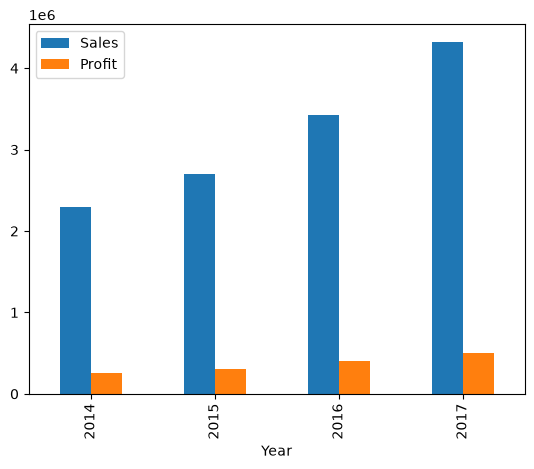

In [212]:
# Graph to identify important trends
orders_full.groupby("Year")[["Sales", "Profit"]].sum().plot(kind="bar")

In [222]:
orders_full.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Shipping Cost,Order Priority,Shipping Duration,Profit Margin,Returned,Region_Returns,Person,Region,First Word,Year
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,39.66,Medium,7,13.995245,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia,Ikea,2017
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,18.72,Medium,3,42.904656,No,Not returned,Chandrakant Chaudhri,Southern Asia,Acme,2015
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,14.10,Medium,7,3.976091,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia,Epson,2017
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,Unknown,Herat,...,11.01,Medium,7,46.958982,Yes,Southern Asia,Chandrakant Chaudhri,Southern Asia,Rubbermaid,2017
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,Unknown,Herat,...,5.72,Medium,3,11.948205,No,Not returned,Chandrakant Chaudhri,Southern Asia,Cameo,2015


### 9. Use Hierarchical Indexing

In [ ]:
# Grouping Category and Sub-Category Sales and Profit
cat_sub = orders_full.groupby(["Category", "Sub-Category"])[["Sales", "Profit"]].sum()
cat_sub

Sales        Profit
Category        Sub-Category                            
Furniture       Bookcases     1.481056e+06  165291.07840
                Chairs        1.517118e+06  141930.18150
                Furnishings   3.866438e+05   47269.99330
                Tables        7.590457e+05  -63805.13270
Office Supplies Appliances    1.016326e+06  141754.27050
                Art           3.728395e+05   57888.86470
                Binders       4.635701e+05   72526.50620
                Envelopes     1.700663e+05   28839.67430
                Fasteners     8.989883e+04   13827.24740
                Labels        7.351599e+04   15029.84710
                Paper         2.432572e+05   58535.52610
                Storage       1.135103e+06  108586.32760
                Supplies      2.438336e+05   22691.10280
Technology      Accessories   7.556640e+05  130455.38420
                Copiers       1.523847e+06  262136.49428
                Machines      7.919086e+05   53292.53550
                Phones        1.715790e+06  217812.51440

In [ ]:
# Locating Sales and Profit for the Furniture Sub-Category
cat_sub.loc["Furniture"]

,Sales,Profit
Sub-Category,,
Bookcases,1.481056e+06,165291.0784
Chairs,1.517118e+06,141930.1815
Furnishings,3.866438e+05,47269.9933
Tables,7.590457e+05,-63805.1327


In [ ]:
cat_sub.loc[("Furniture", "Chairs")]

Sales     1.517118e+06
Profit    1.419302e+05
Name: (Furniture, Chairs), dtype: float64

In [218]:
cat_sub.xs("Chairs", level="Sub-Category")

,Sales,Profit
Category,,
Furniture,1.517118e+06,141930.1815


In [219]:
print("Most profitable: ", cat_sub["Profit"].idxmax())
print("Least profitable:", cat_sub["Profit"].idxmin())

Most profitable:  ('Technology', 'Copiers')
Least profitable: ('Furniture', 'Tables')


### 10. Present Your Findings

In [223]:
print("BEST MARKETS BY PROFIT")
print(orders_full.groupby("Market")["Profit"].sum().sort_values(ascending=False), "\n")

print("BEST REGIONS BY PROFIT (top 5)")
print(orders_full.groupby("Region_Orders")["Profit"].sum().sort_values(ascending=False).head(5), "\n")

print("PROFIT BY CATEGORY")
print(orders_full.groupby("Category")["Profit"].sum().sort_values(ascending=False), "\n")

BEST MARKETS BY PROFIT
Market
Europe          450793.92750
Asia Pacific    407226.25700
USCA            301301.53380
LATAM           225176.53128
Africa           89564.16600
Name: Profit, dtype: float64 

BEST REGIONS BY PROFIT (top 5)
Region_Orders
Western Europe     220189.64250
Eastern Asia       168688.43100
Southern Asia      162661.32700
Central America    161993.83272
Oceania            120084.57600
Name: Profit, dtype: float64 

PROFIT BY CATEGORY
Category
Technology         663696.92838
Office Supplies    519679.36670
Furniture          290686.12050
Name: Profit, dtype: float64 



In [225]:
print("PROFIT BY SUB-CATEGORY")
print(orders_full.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False), "\n")

print("SALES BY SEGMENT")
print(orders_full.groupby("Segment")["Sales"].sum().sort_values(ascending=False), "\n")

PROFIT BY SUB-CATEGORY
Sub-Category
Copiers        262136.49428
Phones         217812.51440
Bookcases      165291.07840
Chairs         141930.18150
Appliances     141754.27050
Accessories    130455.38420
Storage        108586.32760
Binders         72526.50620
Paper           58535.52610
Art             57888.86470
Machines        53292.53550
Furnishings     47269.99330
Envelopes       28839.67430
Supplies        22691.10280
Labels          15029.84710
Fasteners       13827.24740
Tables         -63805.13270
Name: Profit, dtype: float64 

SALES BY SEGMENT
Segment
Consumer       6.542192e+06
Corporate      3.858145e+06
Home Office    2.339148e+06
Name: Sales, dtype: float64 



In [227]:
print("AVERAGE PROFIT BY DISCOUNT LEVEL")
print(orders_full.groupby("Discount")["Profit"].mean().round(1), "\n")

AVERAGE PROFIT BY DISCOUNT LEVEL
Discount
0.000      61.1
0.002     126.7
0.070     141.0
0.100      63.7
0.150      50.4
0.170      38.3
0.200      23.5
0.202     -14.5
0.250       4.7
0.270      -4.3
0.300     -57.6
0.320     -88.6
0.350    -115.6
0.370     -78.5
0.400     -45.6
0.402    -109.9
0.450     -40.9
0.470     -43.0
0.500     -97.0
0.550    -315.1
0.570    -526.1
0.600     -81.8
0.602    -213.3
0.650    -366.0
0.700    -106.1
0.800    -123.2
0.850   -1534.3
Name: Profit, dtype: float64 



In [232]:
print("SALES BY YEAR")
print(orders_full.groupby("Year")["Sales"].sum().round(2))

SALES BY YEAR
Year
2014    2290775.60
2015    2698023.05
2016    3426598.34
2017    4324087.73
Name: Sales, dtype: float64


1. Which markets or regions perform best?
    - Europe. It has the highest profit of any market, at about 450k. Asia Pacific has the highest sales but lower profit, which is an interesting detail.

2. Which categories and sub-categories are most profitable?
    - Technology for categories and Copiers for sub-categories.

3. Which customer segment generates the most sales?
    - Consumer has the most sales

4. How does discounting relate to profit?
    - Profit falls as discounts rise. Average profit per order line is positive at low discounts, and turns negative at around 20% and above.

5. How does sales performance change over time?
    - Sales grew every year from 2014 to 2017, from about 2.3M to 4.3M.

6. What other interesting patterns did you discover?
    - The sub-category tables is losing money Tables

## Business Summary

Overall, the company is growing: sales rose every year from 2014 to 2017, from about 2.3M to 4.3M. Europe is the most profitable market (about 450k), while Asia Pacific sells the most but earns less profit, which suggests its margins are weaker. Technology is the most profitable category, with Copiers the top sub-category, and the Consumer segment brings in the most sales.

The main concern is discounting. Profit per order falls as discounts rise and turns negative at around 20% and above, and the Tables sub-category loses money overall (about -64k). I recommend capping discounts, especially on Tables, and looking into why Asia Pacific's profit lags behind its sales.